# Map Generation Test Notebook

This notebook demonstrates the `cartoblobpy` map generation functionality. It takes geographic coordinates (latitude/longitude bounds) and generates maps with ROS-compatible YAML configuration files.

The workflow:
1. Define geographic bounding box parameters (latitude top/bottom, longitude left/right)
2. Call `generate_map()` with these coordinates
3. The function fetches OSM data, processes coastlines, and classifies land/water
4. Outputs PNG map image and YAML metadata file


## Section 1: Import Required Libraries

Import necessary libraries for the map generation workflow.

In [1]:
import sys
from pathlib import Path
import yaml
from IPython.display import Image, display
import matplotlib.pyplot as plt

# Add src to path to import cartoblobpy
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# from cartoblobpy import generate_map
import cartoblobpy
from cartoblobpy.map_generation import generate_map

## Section 2: Define Geographic Parameters

Set the geographic bounding box and rendering configuration. The function automatically classifies land/water using the coastline topology—no manual calibration points needed!

In [ ]:
# Geographic bounding box for Trondheim fjord (WGS84)
# LAT_TOP   = 63.470   # Top latitude
# LAT_BOT   = 63.400   # Bottom latitude
# LON_LEFT  = 10.320   # Left longitude
# LON_RIGHT = 10.510   # Right longitude

LAT_TOP, LON_LEFT= 63.535064, 10.071646

LAT_BOT, LON_RIGHT = 63.413638, 10.539811




# Rendering parameters
OUTPUT_IMAGE = "trondheim_fjord.png"
OUTPUT_YAML = "trondheim_fjord.yaml"
DPI = 300
FIG_HEIGHT_INCHES = 10

# Colors
COLOR_WATER = "#FFFFFF"
COLOR_LAND = "#000000"



print(f"Geographic bounds:")
print(f"  Latitude:  {LAT_BOT:.3f} to {LAT_TOP:.3f}")
print(f"  Longitude: {LON_LEFT:.3f} to {LON_RIGHT:.3f}")
print(f"\nOutput files:")
print(f"  Image: {OUTPUT_IMAGE}")
print(f"  YAML:  {OUTPUT_YAML}")

Geographic bounds:
  Latitude:  63.414 to 63.535
  Longitude: 10.072 to 10.540

Output files:
  Image: trondheim_fjord.png
  YAML:  trondheim_fjord.yaml


## Section 3: Generate Map and YAML

Call the `generate_map()` function with just the geographic bounds and configuration parameters. The function will:
- Fetch OpenStreetMap data (coastlines and water features)
- Automatically detect the appropriate UTM projection zone
- **Automatically classify land/water regions** using topological analysis (no calibration points needed!)
- Generate PNG image and YAML metadata file

Generating map from geographic coordinates...
Auto-detected projection: EPSG:32632
UTM bounding box: 23048.6 x 14003.3 m
  BL: (553510.3, 7032124.4)
  TR: (576558.9, 7046127.8)
  90 coastline line(s)
  4 closed coastline polygon(s) (islands)
  16 place=island/islet polygon(s)
  7 clipped segment(s)
  20 island polygon(s)
  7 candidate polygon(s)
  7 valid polygon(s)
  Island detected: area=83682.0 m2, centroid=(569179.1, 7034658.4) UTM
  Island detected: area=500586.6 m2, centroid=(570038.0, 7035316.7) UTM
  Island detected: area=691.7 m2, centroid=(574273.8, 7035515.0) UTM
  Island detected: area=209.0 m2, centroid=(574306.3, 7035473.6) UTM
  Island detected: area=80668.6 m2, centroid=(575237.3, 7035195.7) UTM
  26 land (incl. islands), 1 water

  Extent: 23048.6 x 14003.3 m
  Figure: 16.46 x 10 in -> 4938 x 3000 px
  Resolution: 4.667779 m/px
Fetching inland water features...
  347 inland water polygon(s)
  250 waterway line(s)

Map generation completed successfully!


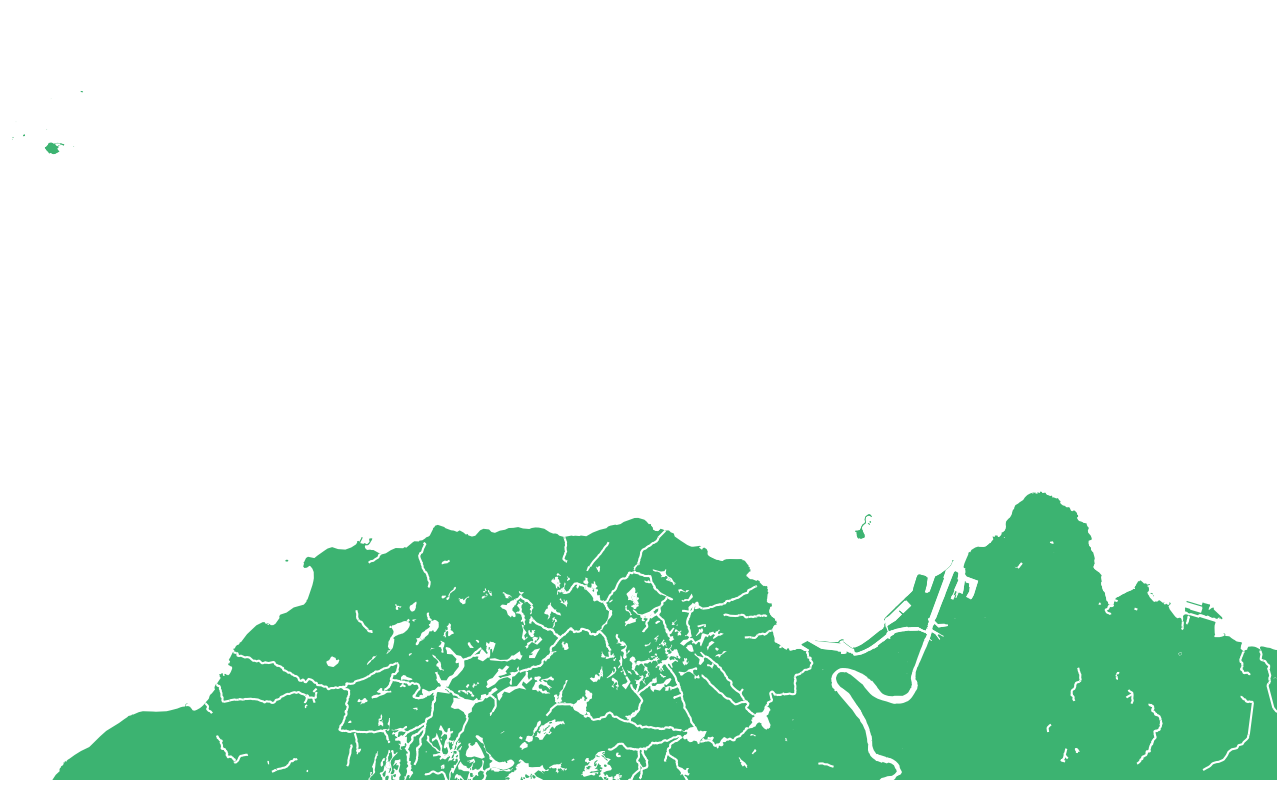

In [7]:
print("Generating map from geographic coordinates...")
print("=" * 60)


# Call the generate_map function with geographic bounds and rendering parameters
map_info = generate_map(
    lat_top=LAT_TOP,
    lat_bottom=LAT_BOT,
    lon_left=LON_LEFT,
    lon_right=LON_RIGHT,
    output_image=OUTPUT_IMAGE,
    output_yaml=OUTPUT_YAML,
    dpi=DPI,
    fig_height_inches=FIG_HEIGHT_INCHES,
    color_water=COLOR_WATER,
    color_land=COLOR_LAND,
)

print("=" * 60)
print("\nMap generation completed successfully!")

## Section 4: Verify Output Files

Check that both output files were created successfully and display their properties.

In [ ]:
import os

# Check PNG file
if os.path.exists(OUTPUT_IMAGE):
    file_size_mb = os.path.getsize(OUTPUT_IMAGE) / (1024 * 1024)
    print(f"PNG Image file exists: {OUTPUT_IMAGE}")
    print(f"Size: {file_size_mb:.2f} MB")
else:
    print(f"PNG file NOT found: {OUTPUT_IMAGE}")

# Check YAML file
if os.path.exists(OUTPUT_YAML):
    file_size_kb = os.path.getsize(OUTPUT_YAML) / 1024
    print(f"\nYAML file exists: {OUTPUT_YAML}")
    print(f"Size: {file_size_kb:.2f} KB")
else:
    print(f"YAML file NOT found: {OUTPUT_YAML}")

print(f"\nMap Information:")
print(f"Resolution: {map_info['resolution']:.6f} m/px")
print(f"Dimensions (pixels): {map_info['dimensions_pixels'][0]} x {map_info['dimensions_pixels'][1]}")
print(f"Dimensions (meters): {map_info['dimensions_meters'][0]:.1f} x {map_info['dimensions_meters'][1]:.1f}")

PNG Image file exists: trondheim_fjord.png
Size: 0.24 MB

YAML file exists: trondheim_fjord.yaml
Size: 0.13 KB

Map Information:
Resolution: 2.669221 m/px
Dimensions (pixels): 3487 x 3000
Dimensions (meters): 9306.5 x 8007.7


## Section 5: Display Generated Map

Load and display the generated map image along with the YAML configuration.

GENERATED MAP IMAGE


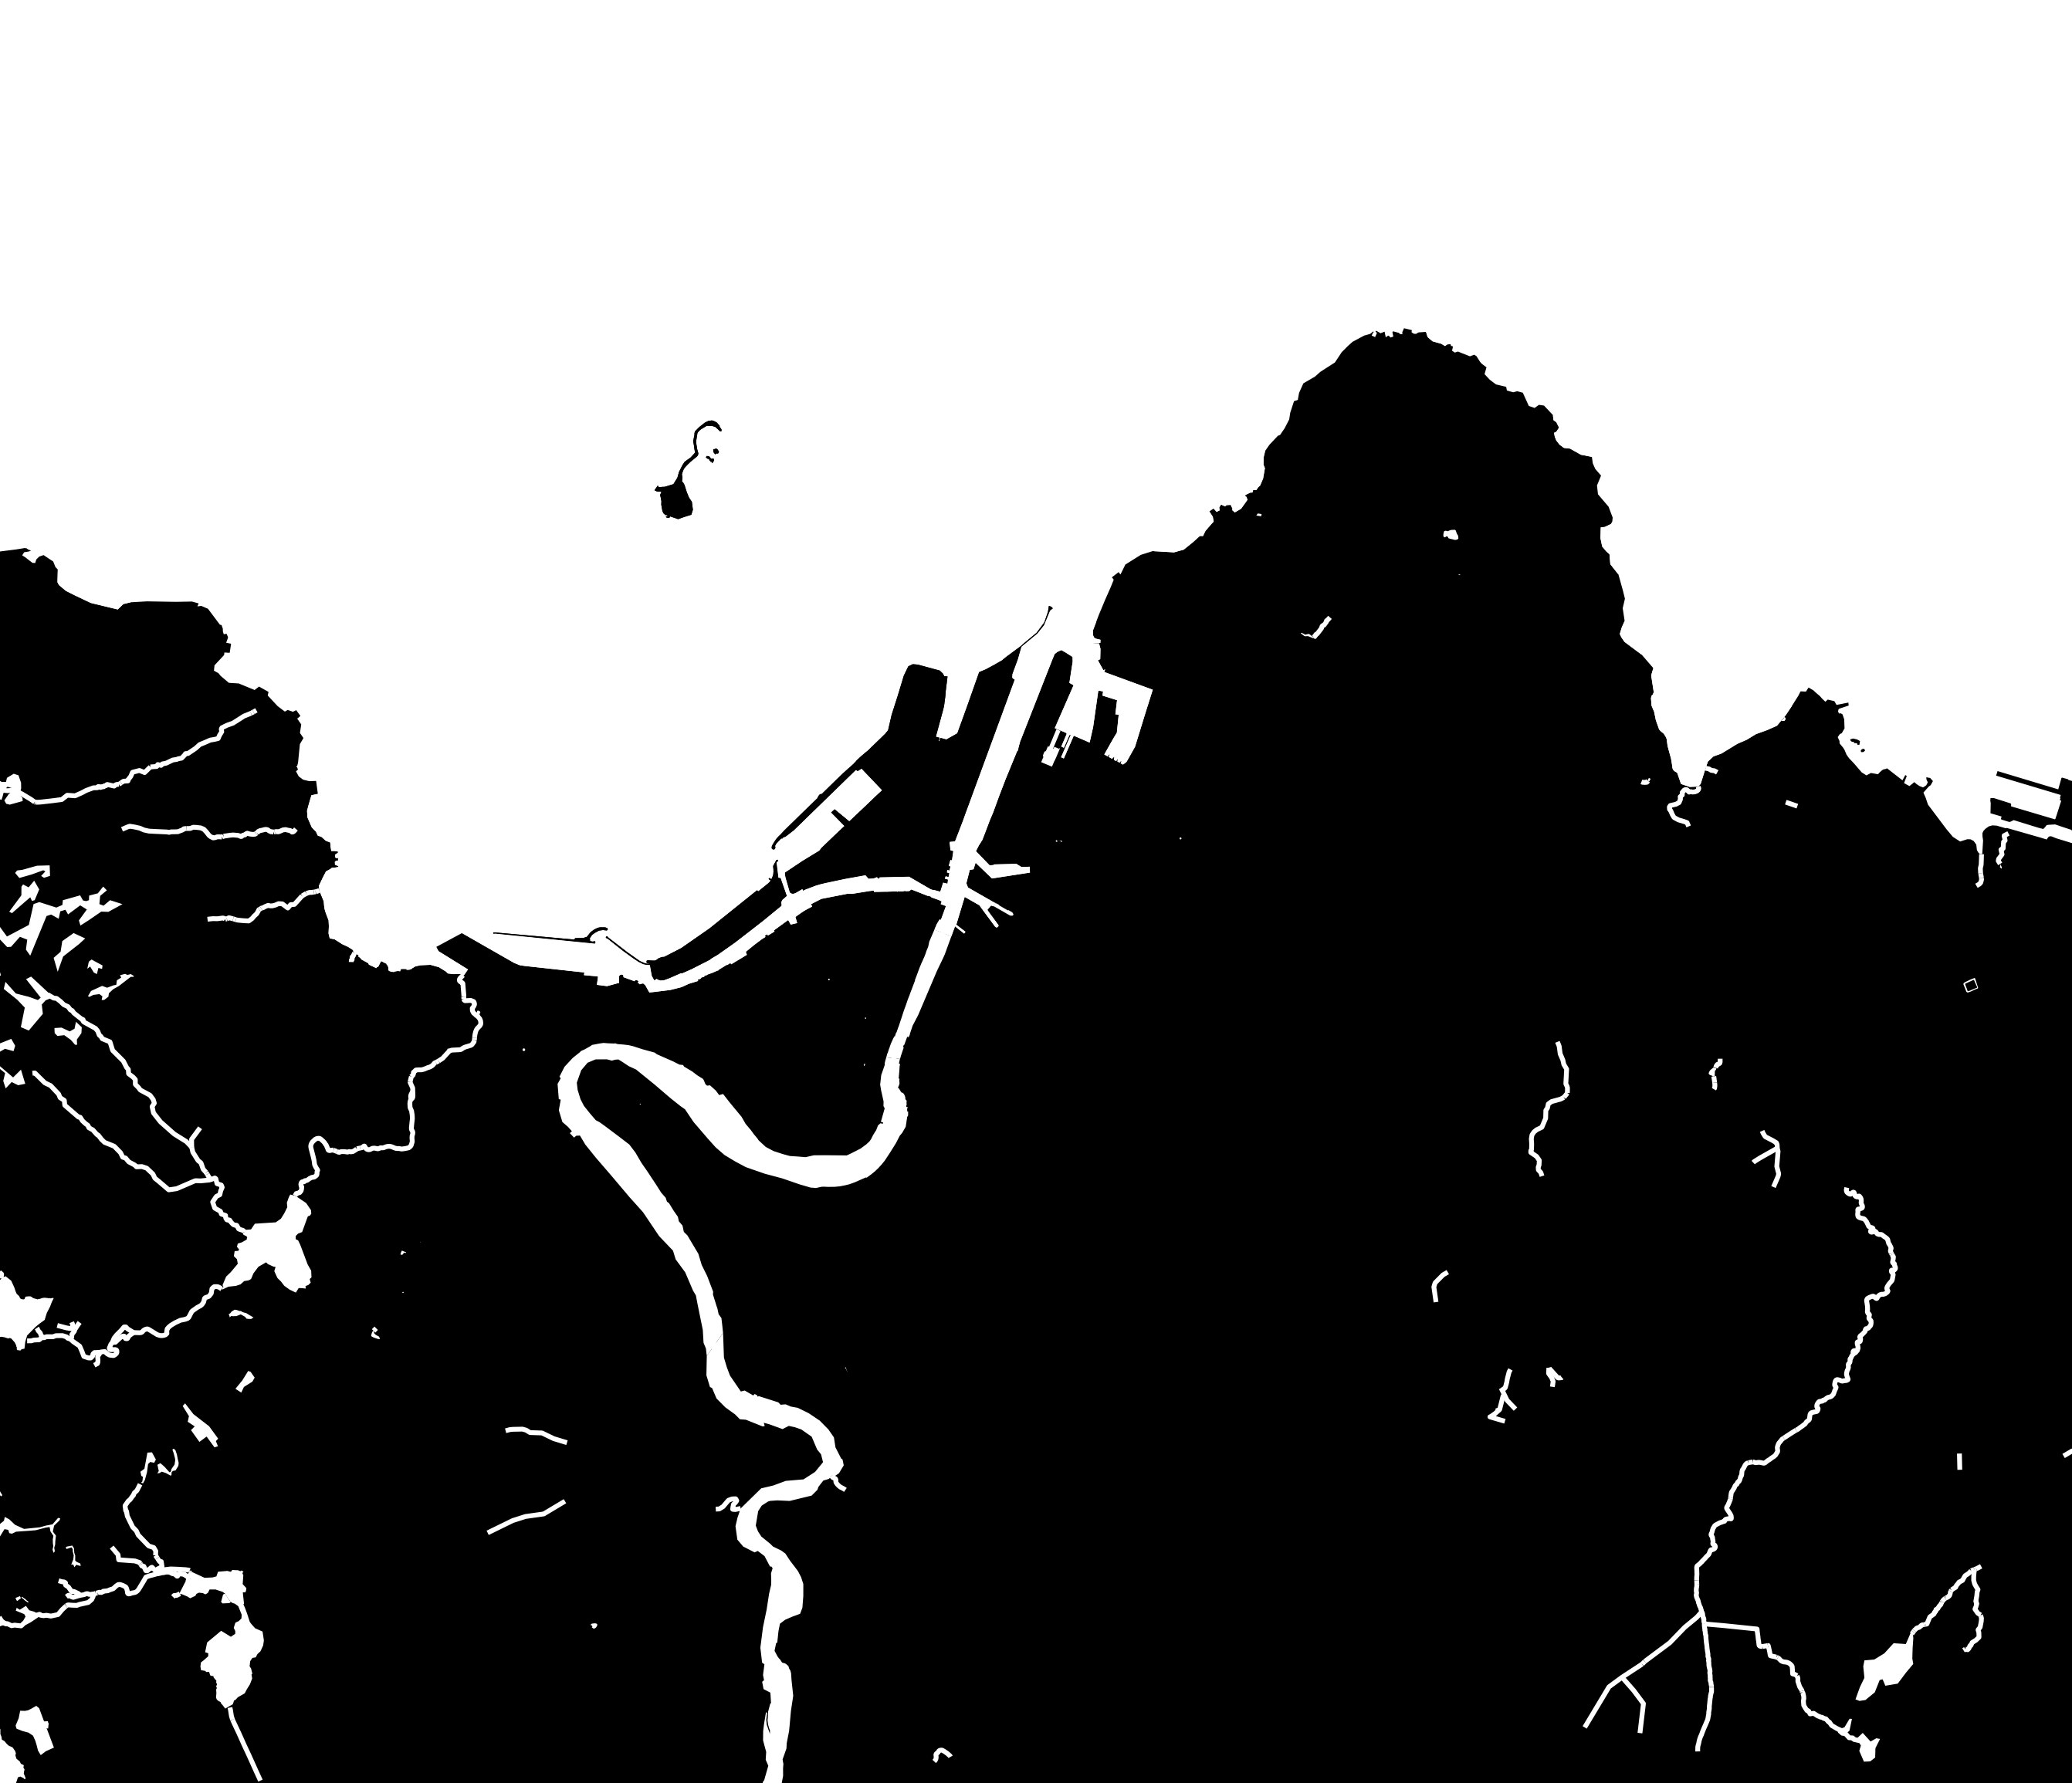


YAML CONFIGURATION

Parsed YAML Configuration:
  image: ./trondheim_fjord.png
  resolution: 2.669221
  origin: [0.0, 0.0, 0.0]
  negate: 0
  occupied_thresh: 0.65
  free_thresh: 0.196

Raw YAML Content:
image: ./trondheim_fjord.png
resolution: 2.669221
origin:
- 0.0
- 0.0
- 0.0
negate: 0
occupied_thresh: 0.65
free_thresh: 0.196



In [ ]:
print("=" * 60)
print("GENERATED MAP IMAGE")
print("=" * 60)

# Display the generated map
if os.path.exists(OUTPUT_IMAGE):
    display(Image(filename=OUTPUT_IMAGE))
else:
    print("Map image file not found!")

print("\n" + "=" * 60)
print("YAML CONFIGURATION")
print("=" * 60 + "\n")

# Load and display YAML content
if os.path.exists(OUTPUT_YAML):
    with open(OUTPUT_YAML, 'r') as f:
        yaml_content = yaml.safe_load(f)

    print("Parsed YAML Configuration:")
    for key, value in yaml_content.items():
        print(f"  {key}: {value}")

    print("\nRaw YAML Content:")
    with open(OUTPUT_YAML, 'r') as f:
        print(f.read())
else:
    print("YAML file not found!")

## Notes: Using Different Geographic Coordinates

To generate maps for other regions, simply update the geographic parameters in Section 2:

1. **Modify the bounding box:**
   - `LAT_TOP` and `LAT_BOT`: Set the latitude boundaries (use negative values for southern hemisphere)
   - `LON_LEFT` and `LON_RIGHT`: Set the longitude boundaries (use negative for western hemisphere)

2. **Customize rendering (optional):**
   - `DPI`: Higher values create higher resolution images (default: 300)
   - `FIG_HEIGHT_INCHES`: Adjust map size (default: 10 inches)
   - `COLOR_WATER` and `COLOR_LAND`: Change colors using hex codes

3. **Update output filenames (optional):**
   - `OUTPUT_IMAGE`: PNG filename (default: "map.png")
   - `OUTPUT_YAML`: YAML metadata filename (default: "map.yaml")

### How It Works

The algorithm **automatically classifies land vs water** without requiring manual calibration points:

1. Fetches OSM coastline data and reprojects to UTM (true metric coordinates)
2. Polygonizes the coastlines to identify candidate land/water regions
3. Uses a **flood-fill algorithm** with topological edge classification:
   - Edges are classified as either "coastline" or "boundary" edges
   - Starting from the top-center of the map (typically open water), the algorithm flood-fills
   - Upon crossing a coastline edge, it flips land/water classification
   - Interior regions (islands) with no bbox contact are marked as land
4. Renders green for land, blue for water, and outputs ROS-compatible YAML

### Example: Other Norwegian Cities

**Bergen Fjord:**
```python
LAT_TOP = 60.45
LAT_BOT = 60.35
LON_LEFT = 5.25
LON_RIGHT = 5.50
```

**Oslo Fjord:**
```python
LAT_TOP = 59.95
LAT_BOT = 59.80
LON_LEFT = 10.50
LON_RIGHT = 10.80
```

The function automatically detects the correct UTM projection zone for any coordinate pair on Earth!